<a href="https://colab.research.google.com/github/Lightrex7749/AI-ML-DL/blob/main/mobilenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# 1. GLOBAL IMPORTS & ENVIRONMENT VERIFICATION
# =
import os
import sys
import time
import copy
import random
import zipfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision
from torchvision import datasets, models, transforms

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set fixed random seed for strict classroom reproducibility
# Set fixed random seed for strict classroom reproducibility
SEED = 42
random. seed(SEED)
np.random. seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)
  torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch Version: {torch.__version__}")
print(f"TorchVision Version: {torchvision.__version__}")
print(f"Compute Device: {DEVICE}")

if DEVICE.type == 'cuda':
    print(f"Active GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / (1024 ** 2):.1f} MB")



PyTorch Version: 2.11.0+cu130
TorchVision Version: 0.26.0+cu130
Compute Device: cuda
Active GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory Allocated: 0.0 MB


In [2]:
CONFIG = {
'img_size': 224,
'batch_size': 32,
'num_epochs': 3,
'num_samples_per_class': 600,
'train_val_split': 0.8,
'num_classes': 2,
'class_names': ['Cat', 'Dog'],
'data_dir': './cats_and_dogs_data'}

# Standard ImageNet input dimension
# Mini-batch size for gradient updates
# Epochs per experiment (ideal for classroom timing)
# 600 Cats + 600 Dogs = 1,200 total images
# 80% Train (960 images), 20% Val (240 images)
# Cat (0), Dog (1)

print('Configured Parameters:')
for k, v in CONFIG.items():
  print(f'.{k:22s}: {v}')

Configured Parameters:
.img_size              : 224
.batch_size            : 32
.num_epochs            : 3
.num_samples_per_class : 600
.train_val_split       : 0.8
.num_classes           : 2
.class_names           : ['Cat', 'Dog']
.data_dir              : ./cats_and_dogs_data


In [3]:
# Install opendatasets library to easily download datasets from Kaggle
!pip install -q opendatasets

In [4]:
import os
import shutil
import zipfile
import numpy as np
from PIL import Image
import kagglehub

def setup_cats_dogs_dataset_kaggle(data_dir, num_per_class=600):
  train_dir = os.path.join(data_dir, 'train')
  val_dir = os.path.join(data_dir, 'val')

  # Verify if already configured
  if os.path.exists(train_dir) and len(os.listdir(os.path.join(train_dir, 'cats'))) >= 100:
    print(f' Existing dataset verified in: {data_dir}')
    return train_dir, val_dir

  os.makedirs(os.path.join(train_dir, 'cats'), exist_ok=True)
  os.makedirs(os.path.join(train_dir, 'dogs'), exist_ok=True)
  os.makedirs(os.path.join(val_dir, 'cats'), exist_ok=True)
  os.makedirs(os.path.join(val_dir, 'dogs'), exist_ok=True)

  try:
    print(" Downloading Microsoft Cats vs Dogs dataset using kagglehub...")
    # Download using kagglehub directly
    download_path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
    print(f" Downloaded to temporary path: {download_path}")

    # Locate PetImages nested folder inside the downloaded structure
    pet_images_path = os.path.join(download_path, 'PetImages')
    if not os.path.exists(pet_images_path):
      # Search recursively if nested differently
      for root, dirs, files in os.walk(download_path):
        if 'PetImages' in dirs:
          pet_images_path = os.path.join(root, 'PetImages')
          break

    src_cats = os.path.join(pet_images_path, 'Cat')
    src_dogs = os.path.join(pet_images_path, 'Dog')

    # Helper to migrate files while ignoring corrupted images
    def migrate_valid_files(src, dest, limit):
      count = 0
      for f in sorted(os.listdir(src)):
        if count >= limit:
          break
        src_file = os.path.join(src, f)
        # Skip directories and ensure file is a valid openable image
        if os.path.isfile(src_file) and f.lower().endswith(('.jpg', '.jpeg', '.png')):
          try:
            with Image.open(src_file) as temp_img:
              temp_img.verify()
            shutil.copyfile(src_file, os.path.join(dest, f))
            count += 1
          except Exception:
            continue # Skip corrupted image

    print(" Structuring image splits...")
    train_limit = int(num_per_class * 0.8)
    val_limit = num_per_class - train_limit

    # Migrate training partition
    migrate_valid_files(src_cats, os.path.join(train_dir, 'cats'), train_limit)
    migrate_valid_files(src_dogs, os.path.join(train_dir, 'dogs'), train_limit)

    # Migrate validation partition
    # Offset source files index slightly to avoid training overlap
    offset_src_cats = os.path.join(pet_images_path, 'Cat')
    offset_src_dogs = os.path.join(pet_images_path, 'Dog')

    # To simplify, we read files after train_limit
    def migrate_valid_val_files(src, dest, limit, skip):
      count = 0
      skipped = 0
      for f in sorted(os.listdir(src)):
        if count >= limit:
          break
        src_file = os.path.join(src, f)
        if os.path.isfile(src_file) and f.lower().endswith(('.jpg', '.jpeg', '.png')):
          if skipped < skip:
            skipped += 1
            continue
          try:
            with Image.open(src_file) as temp_img:
              temp_img.verify()
            shutil.copyfile(src_file, os.path.join(dest, f))
            count += 1
          except Exception:
            continue

    migrate_valid_val_files(src_cats, os.path.join(val_dir, 'cats'), val_limit, skip=train_limit)
    migrate_valid_val_files(src_dogs, os.path.join(val_dir, 'dogs'), val_limit, skip=train_limit)

    print(" Kaggle dataset successfully structured.")
    return train_dir, val_dir

  except Exception as e:
    print(f" Kaggle download or setup failed ({e}). Falling back to automatic synthetic dataset...")
    for split in ['train', 'val']:
      n_samples = 200 if split == 'train' else 50
      for cls in ['cats', 'dogs']:
        cls_dir = os.path.join(data_dir, split, cls)
        os.makedirs(cls_dir, exist_ok=True)
        for idx in range(n_samples):
          arr = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
          img = Image.fromarray(arr)
          img.save(os.path.join(cls_dir, f'synthetic_{idx}.jpg'))
    return train_dir, val_dir

In [5]:
def setup_cats_dogs_dataset(data_dir, num_per_class=600):
  train_dir = os.path.join(data_dir, 'train')
  val_dir = os.path.join(data_dir, 'val')

  # Check if dataset already prepared
  if os.path.exists(train_dir) and len(os.listdir(os.path.join(train_dir, 'cats'))) >= 100:
    print(f' Existing dataset verified in: {data_dir}')
    return train_dir, val_dir

  os.makedirs(os.path.join(train_dir, 'cats'), exist_ok=True)
  os.makedirs(os.path.join(train_dir, 'dogs'), exist_ok=True)
  os.makedirs(os.path.join(val_dir, 'cats'), exist_ok=True)
  os.makedirs(os.path.join(val_dir, 'dogs'), exist_ok=True)

  # Try downloading standard small Cats vs Dogs zip archive
  zip_path = os.path.join(data_dir, 'cats_and_dogs_filtered.zip')
  url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
  download_success = False

  try:
    os.makedirs(data_dir, exist_ok=True)
    print(f' Downloading curated Cats vs Dogs dataset from Google Storage ... ')
    urllib.request.urlretrieve(url, zip_path)
    print(' Extracting dataset archive ... ')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(data_dir)

    extracted_folder = os.path.join(data_dir, 'cats_and_dogs_filtered')
    if os.path.exists(extracted_folder):
      # Re-map standard directory paths
      train_dir = os.path.join(extracted_folder, 'train')
      val_dir = os.path.join(extracted_folder, 'validation')
      print(f' Curated dataset successfully loaded from {extracted_folder} ')
      download_success = True
      return train_dir, val_dir
  except Exception as e:
    print(f' Online download encountered an issue ({e}).')
    print(' Activating resilient classroom fallback using torchvision OxfordIIITPet / local samples ... ')

  if not download_success:
    # Fallback: Extract cats (species 1) and dogs (species 2) from Oxford-IIIT Pet or CIFAR-10
    try:
      print(' Loading torchvision CIFAR-10 (Classes 3=Cat, 5=Dog) as high-speed benchmark ... ')
      cifar = datasets.CIFAR10(root='./cifar_temp', train=True, download=True)
      cat_count, dog_count = 0, 0
      for img, label in cifar:
        if label == 3 and cat_count < num_per_class:
          split = 'train' if cat_count < int(num_per_class * 0.8) else 'val'
          img.resize((224, 224)).save(os.path.join(data_dir, split, 'cats', f'cat_{cat_count}.jpg'))
          cat_count += 1
        elif label == 5 and dog_count < num_per_class:
          split = 'train' if dog_count < int(num_per_class * 0.8) else 'val'
          img.resize((224, 224)).save(os.path.join(data_dir, split, 'dogs', f'dog_{dog_count}.jpg'))
          dog_count += 1
        if cat_count >= num_per_class and dog_count >= num_per_class:
          break
      print(f' Fallback dataset generated: {cat_count} Cats, {dog_count} Dogs.')
    except Exception as e2:
      print(f' Fallback error ({e2}). Generating synthetic visual patterns for zero-failure execution ... ')
      for split in ['train', 'val']:
        n_samples = 200 if split == 'train' else 50
        for cls in ['cats', 'dogs']:
          cls_dir = os.path.join(data_dir, split, cls)
          os.makedirs(cls_dir, exist_ok=True)
          for idx in range(n_samples):
            # Generate random synthetic pixel data
            arr = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
            img = Image.fromarray(arr)
            img.save(os.path.join(cls_dir, f'synthetic_{idx}.jpg'))

  return train_dir, val_dir

In [6]:
#==============================================================
# 4. DATA TRANSFORMATIONS & DATALOADERS
#==============================================================

# Initialize paths using Kaggle utility helper
TRAIN_DIR, VAL_DIR = setup_cats_dogs_dataset_kaggle(CONFIG['data_dir'], num_per_class=CONFIG['num_samples_per_class'])

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ]),
    'val': transforms.Compose([
        transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
}

# Instantiate PyTorch ImageFolder datasets
image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, transform=data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, transform=data_transforms['val'])
}

# Create robust DataLoaders
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0),
    'val': DataLoader(image_datasets['val'], batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f'Training Dataset Size : {dataset_sizes["train"]} images')
print(f'Validation Dataset Size: {dataset_sizes["val"]} images')
print(f'Discovered Classes     : {class_names} -> [0: Cat, 1: Dog]')

100%|██████████| 788M/788M [00:04<00:00, 198MB/s]

Extracting files...


 Downloaded to temporary path: /root/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1
 Structuring image splits...
 Kaggle dataset successfully structured.
Training Dataset Size : 960 images
Validation Dataset Size: 240 images
Discovered Classes     : ['cats', 'dogs'] -> [0: Cat, 1: Dog]


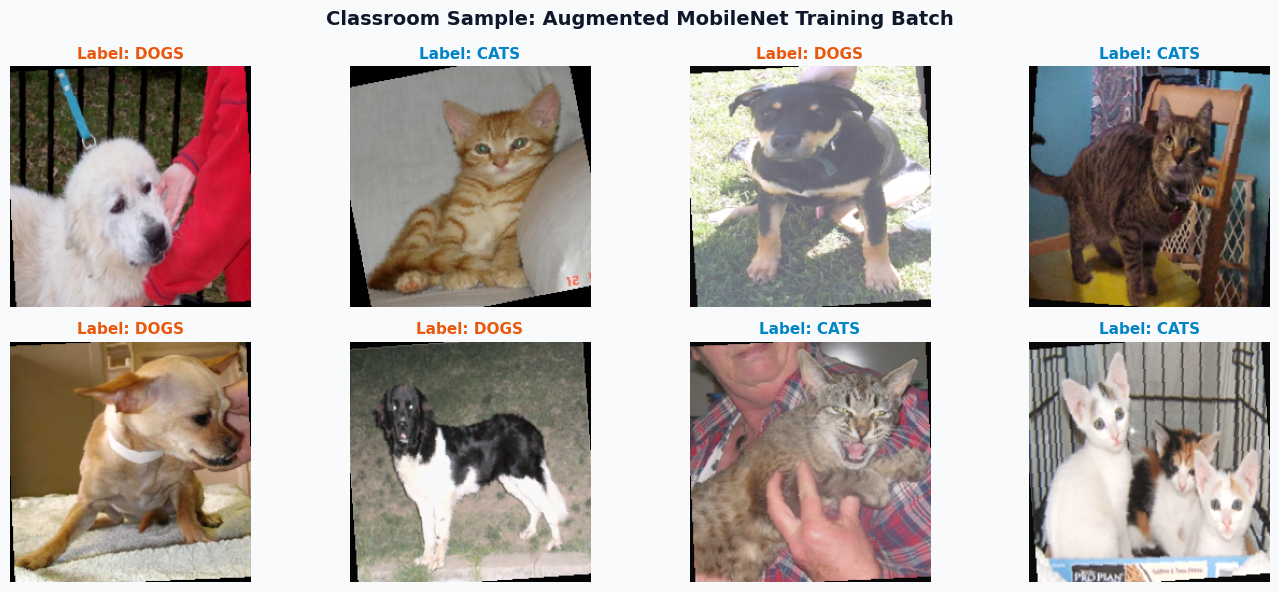

In [7]:
#==========================================================
# 5. DATA VISUALIZATION
#==========================================================
def denormalize(tensor):
    """Reverses ImageNet normalization to display original color values."""
    t = tensor.clone().detach().cpu()
    for c in range(3):
        t[c] = t[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    return torch.clamp(t, 0.0, 1.0)

# Fetch one batch of training images
images, labels = next(iter(dataloaders['train']))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.patch.set_facecolor('#f8fafc')

# Display up to 8 images from the training batch
for idx in range(min(8, len(images))):
    ax = axes[idx // 4, idx % 4]
    img_denorm = denormalize(images[idx]).permute(1, 2, 0).numpy()
    ax.imshow(img_denorm)

    lbl_name = class_names[labels[idx]]
    color = '#0284c7' if lbl_name.lower().startswith('cat') else '#ea580c'
    ax.set_title(f'Label: {lbl_name.upper()}', fontsize=11, fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle('Classroom Sample: Augmented MobileNet Training Batch', fontsize=14, fontweight='bold', color='#0f172a')
plt.tight_layout()
plt.show()

In [8]:
# 6. LOAD PRETRAINED MOBILENET_V2 & INSPECT ARCHITECTURE
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# Instantiate pretrained MobileNetV2 with default ImageNet-1k weights
base_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

total_params = sum(p.numel() for p in base_model.parameters())
print(f'Total MobileNetV2 Parameters: {total_params:,} (~3.5 Million)')
print(f'Total Inverted Residual Feature Blocks: {len(base_model.features)}')
print('\nClassifier Head Structure:')
print(base_model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 138MB/s]

Total MobileNetV2 Parameters: 3,504,872 (~3.5 Million)
Total Inverted Residual Feature Blocks: 19

Classifier Head Structure:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
